# Recap and Task Definition

Track B - Advanced Regression

 In the previous part, we trained regression models  predict future prices, and models using historical price information achieved extremely high performance, meaning that previous prices contained most of the predictive information.

In P3, we extend the analysis by comparing more advanced machine learning models, applying hyperparameter tuning, and exploring unsupervised learning techniques such as PCA and K-Means clustering. 

We are particularly interested in evaluating how well prices can be predicted without relying directly on historical price values and whether economic and geographic features alone contain meaningful predictive information.

# Dataset Preparation

Unlike P2, price history features are removed to test whether future food prices can be estimated from other ecomomic, item-category etc. variables.

In [1]:
import pandas as pd
df = pd.read_csv("cleaned_food_prices.csv")
df["Month"] = pd.to_datetime(df["Month"])

df = df.sort_values(
    ["Country", "City", "Item", "Month"]
).reset_index(drop=True)

In [2]:
month_order = {
    month: idx + 1
    for idx, month in enumerate(sorted(df["Month"].unique()))
}

df["Time_Index"] = df["Month"].map(month_order)

price_pivot = df.pivot_table(
    index=["Country", "City", "Item", "Item_Category", "Continent"],
    columns="Time_Index",
    values="Price_USD"
).reset_index()

price_pivot.columns = [
    "Country", "City", "Item", "Item_Category", "Continent",
    "Month_1", "Month_2", "Month_3",
    "Month_4", "Month_5", "Month_6"
]

In [3]:
macro_df = (
    df[df["Time_Index"] <= 3]
    .groupby(["Country", "City", "Item"])
    .agg({
        "Exchange_Rate": "mean",
        "YoY_Inflation_Estimate_Pct": "mean",
        "FAO_Index_Value": "mean",
        "Population_Estimate": "mean"
    })
    .reset_index()
)

macro_df = macro_df.rename(columns={
    "Exchange_Rate": "Avg_Exchange_Rate",
    "YoY_Inflation_Estimate_Pct": "Avg_Inflation",
    "FAO_Index_Value": "Avg_FAO_Index",
    "Population_Estimate": "Avg_Population"
})

In [4]:
model_df = pd.merge(
    price_pivot,
    macro_df,
    on=["Country", "City", "Item"],
    how="inner"
)

model_df = model_df.dropna().reset_index(drop=True)

In [5]:
model_df["Future_Avg_Price"] = model_df[
    ["Month_4", "Month_5", "Month_6"]
].mean(axis=1)

In [6]:
feature_cols_no_price = [
    "Country",
    "City",
    "Item",
    "Item_Category",
    "Continent",
    "Avg_Exchange_Rate",
    "Avg_Inflation",
    "Avg_FAO_Index",
    "Avg_Population"
]

target_col = "Future_Avg_Price"

In [7]:
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    cross_val_score
)

cities = model_df["City"].astype(str).unique().tolist()

train_cities, test_cities = train_test_split(
    cities,
    test_size=0.2,
    random_state=42
)

train_df = model_df[model_df["City"].astype(str).isin(train_cities)]
test_df = model_df[model_df["City"].astype(str).isin(test_cities)]

In [8]:
X_train = train_df[feature_cols_no_price]
y_train = train_df[target_col]

X_test = test_df[feature_cols_no_price]
y_test = test_df[target_col]

In [9]:
print(model_df.shape)
print(model_df.head())

(1708, 16)
   Country     City                    Item Item_Category Continent  Month_1  \
0  Algeria  Algiers           apples (1 kg)        Fruits    Africa     3.04   
1  Algeria  Algiers          bananas (1 kg)        Fruits    Africa     1.12   
2  Algeria  Algiers       beef round (1 kg)          Meat    Africa     8.97   
3  Algeria  Algiers  chicken fillets (1 kg)          Meat    Africa     4.60   
4  Algeria  Algiers      eggs (regular, 12)  Dairy & Eggs    Africa     1.74   

   Month_2  Month_3  Month_4  Month_5  Month_6  Avg_Exchange_Rate  \
0     3.25     3.46     3.30     3.43     3.36             0.0074   
1     1.21     1.22     1.17     1.19     1.21             0.0074   
2     9.02     8.77     8.82     9.07     9.06             0.0074   
3     4.58     4.80     4.77     4.90     4.81             0.0074   
4     1.75     1.79     1.74     1.81     1.82             0.0074   

   Avg_Inflation  Avg_FAO_Index  Avg_Population  Future_Avg_Price  
0            9.5     126.

In [10]:
train_cities_final, val_cities = train_test_split(
    train_cities,
    test_size=0.25,
    random_state=42
)

train_df_final = model_df[model_df["City"].astype(str).isin(train_cities_final)]
val_df = model_df[model_df["City"].astype(str).isin(val_cities)]

X_train = train_df_final[feature_cols_no_price]
y_train = train_df_final[target_col]

X_val = val_df[feature_cols_no_price]
y_val = val_df[target_col]

X_test = test_df[feature_cols_no_price]
y_test = test_df[target_col]

In [11]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1008, 9) (1008,)
Validation: (350, 9) (350,)
Test: (350, 9) (350,)


# Unsupervised Analysis

Firstly we will prepare the no-price model, then train the model so that we can tune hyperparameters. Model training part is also included here we mixed the order.

### Regression Training

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_features = [
    "Country",
    "City",
    "Item",
    "Item_Category",
    "Continent"
]

numeric_features = [
    "Avg_Exchange_Rate",
    "Avg_Inflation",
    "Avg_FAO_Index",
    "Avg_Population"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

In [13]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Ridge Regression": Ridge(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_regression_model(name, model, X_train, y_train, X_val, y_val):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    
    return {
        "Model": name,
        "Validation RMSE": rmse,
        "Validation MAE": mae,
        "Validation R2": r2,
        "Pipeline": pipeline
    }

### No-price Model

In [15]:
baseline_results = []

for name, model in models.items():
    result = evaluate_regression_model(
        name,
        model,
        X_train,
        y_train,
        X_val,
        y_val
    )
    baseline_results.append(result)

baseline_results_df = pd.DataFrame(baseline_results).drop(columns=["Pipeline"])
baseline_results_df

,Model,Validation RMSE,Validation MAE,Validation R2
0,Ridge Regression,3.573089,2.029505,0.681221
1,Decision Tree,2.515642,1.176867,0.841984
2,Random Forest,2.723695,1.335647,0.814767
3,Gradient Boosting,2.748820,1.432621,0.811334


### Evaluation:

Decision trees without using any price information actually performed quite well. The model explained %84 of the variance of our data, and it gave an RMSE of 2.51 while std was 5.4, suggesting most of our prediction errors  were in the first half of the variation. So this model is in fact not weak and explains meaningful variance

Decision tree surpassing Random Forest is also a surprise. We can possibly say this single tree exploited some meaningful categories that showed the variance of our data. After tuning parameters with gridsearch we may have different results, maybe random forest had an issue of underfitting that we may resolve. 

Our strongest predictors here are city region item categories rather than inflation, FAO index and population. Therefore the model is probably learning where some items are expensive rather than why they are that way.

## GridSearch Hyperparameter Tuning

In [16]:
from sklearn.model_selection import GridSearchCV

param_grids = {
     "Ridge Regression": {
        "model__alpha": [0.1, 1, 10, 100]
    },
    "Decision Tree": {
        "model__max_depth": [2, 3, 4, 5, 6],
        "model__min_samples_leaf": [10, 20, 30]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [4, 6, 8],
        "model__min_samples_leaf": [10, 20],
        "model__max_features": ["sqrt", 0.5]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3],
        "model__min_samples_leaf": [10, 20]
    }
}

In [17]:
tuned_results = []
best_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    val_preds = grid.best_estimator_.predict(X_val)

    tuned_results.append({
        "Model": name,
        "Best Parameters": grid.best_params_,
        "CV RMSE": -grid.best_score_,
        "Validation RMSE": np.sqrt(mean_squared_error(y_val, val_preds)),
        "Validation MAE": mean_absolute_error(y_val, val_preds),
        "Validation R2": r2_score(y_val, val_preds)
    })

    best_models[name] = grid.best_estimator_

In [18]:
tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,Model,Best Parameters,CV RMSE,Validation RMSE,Validation MAE,Validation R2
0,Ridge Regression,{'model__alpha': 10},2.669456,3.640878,2.023369,0.669010
1,Decision Tree,"{'model__max_depth': 6, 'model__min_samples_le...",2.491347,3.181500,1.746046,0.747265
2,Random Forest,"{'model__max_depth': 8, 'model__max_features':...",2.367938,3.119046,1.566628,0.757090
3,Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",2.047861,2.838569,1.485715,0.798812


Without restricting decision tree performed best again but, we had a depth of 12, which is a gruesome overfitting result. It might seem well but not really learning anything.

Here are more believable results, Gradient boosting performed best here R2 is 0.798 which is an acceptable result without using price values. RMSE was also low and our predictions mostly stayed in the first of half std.

Ridge regerssion was the worst by far, likely normal regression algorithms fail miserably here without price information.

### With Price Data (Continuation of P2)

In [19]:
feature_cols_with_price = [
    "Country", "City", "Item", "Item_Category", "Continent",
    "Month_1", "Month_2", "Month_3",
    "Avg_Exchange_Rate", "Avg_Inflation", "Avg_FAO_Index", "Avg_Population"
]

target_col = "Future_Avg_Price"

In [20]:
X_train_price = train_df_final[feature_cols_with_price]
y_train_price = train_df_final[target_col]

X_val_price = val_df[feature_cols_with_price]
y_val_price = val_df[target_col]

X_test_price = test_df[feature_cols_with_price]
y_test_price = test_df[target_col]

In [21]:
categorical_features_price = [
    "Country", "City", "Item", "Item_Category", "Continent"
]

numeric_features_price = [
    "Month_1", "Month_2", "Month_3",
    "Avg_Exchange_Rate", "Avg_Inflation", "Avg_FAO_Index", "Avg_Population"
]

preprocessor_price = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_price),
        ("num", StandardScaler(), numeric_features_price)
    ]
)

In [22]:
models_price = {
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=10,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        min_samples_leaf=10,
        random_state=42
    )
}

In [23]:
with_price_results = []

for name, model in models_price.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor_price),
        ("model", model)
    ])
    
    pipe.fit(X_train_price, y_train_price)
    preds = pipe.predict(X_val_price)
    
    with_price_results.append({
        "Task": "With price history",
        "Model": name,
        "Validation RMSE": np.sqrt(mean_squared_error(y_val_price, preds)),
        "Validation MAE": mean_absolute_error(y_val_price, preds),
        "Validation R2": r2_score(y_val_price, preds)
    })

with_price_results_df = pd.DataFrame(with_price_results)
with_price_results_df

,Task,Model,Validation RMSE,Validation MAE,Validation R2
0,With price history,Ridge Regression,0.139611,0.069057,0.999513
1,With price history,Random Forest,1.406620,0.265270,0.950597
2,With price history,Gradient Boosting,1.055225,0.215896,0.972197


In [24]:
no_price_summary = tuned_results_df.copy()
no_price_summary["Task"] = "Without price history"

comparison_df = pd.concat([
    no_price_summary[["Task", "Model", "Validation RMSE", "Validation MAE", "Validation R2"]],
    with_price_results_df[["Task", "Model", "Validation RMSE", "Validation MAE", "Validation R2"]]
])

comparison_df.sort_values(["Task", "Validation RMSE"])

,Task,Model,Validation RMSE,Validation MAE,Validation R2
0,With price history,Ridge Regression,0.139611,0.069057,0.999513
2,With price history,Gradient Boosting,1.055225,0.215896,0.972197
1,With price history,Random Forest,1.406620,0.265270,0.950597
3,Without price history,Gradient Boosting,2.838569,1.485715,0.798812
2,Without price history,Random Forest,3.119046,1.566628,0.757090
1,Without price history,Decision Tree,3.181500,1.746046,0.747265
0,Without price history,Ridge Regression,3.640878,2.023369,0.669010


When price data is introduced ridge regression overperformed other models like random forest insanely well. Using first three months data to predict the next 3 makes our problem almost linear and thus regression models become better than the tree based ones.


The tree models also worked really well with price info. R2 values become higher than 0.95, compared to a maximum of 0.8 in the previous models. However we should expect high scores when already having past prices and huge price spikes doesnt exist in our data. So tree based models are still not up to what we want.

# Feature Importance

For the sake of getting a good look at our dataset, we will not use price data and continue with gradboost model in this part.

In [25]:
best_model = best_models["Gradient Boosting"]

In [26]:
feature_names = (
    best_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

In [27]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.named_steps[
        "model"
    ].feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

In [28]:
importance_df.head(20)

,Feature,Importance
130,cat__Item_beef round (1 kg),0.431536
135,cat__Item_local cheese (1 kg),0.196032
156,num__Avg_Inflation,0.129194
147,cat__Item_Category_Meat,0.083563
155,num__Avg_Exchange_Rate,0.051820
131,cat__Item_chicken fillets (1 kg),0.041084
158,num__Avg_Population,0.010335
150,cat__Continent_Asia,0.008965
152,cat__Continent_North America,0.006954
140,cat__Item_tomatoes (1 kg),0.005563


Items like beef and cheese being much more expensive than others, we expected to see them having high importance. Seeing inflation, exchange rate, population and some item categories here is exactly what we wanted though, and it is important to see such metrics here, even if not ranked high. So our model did actually learn stuff even with this lacking dataset.

Apparently city region was not even close to being high predictors instead it was items like meat categories and economical stuff, we can say our model didn't much memorize the data but somewhat learned.

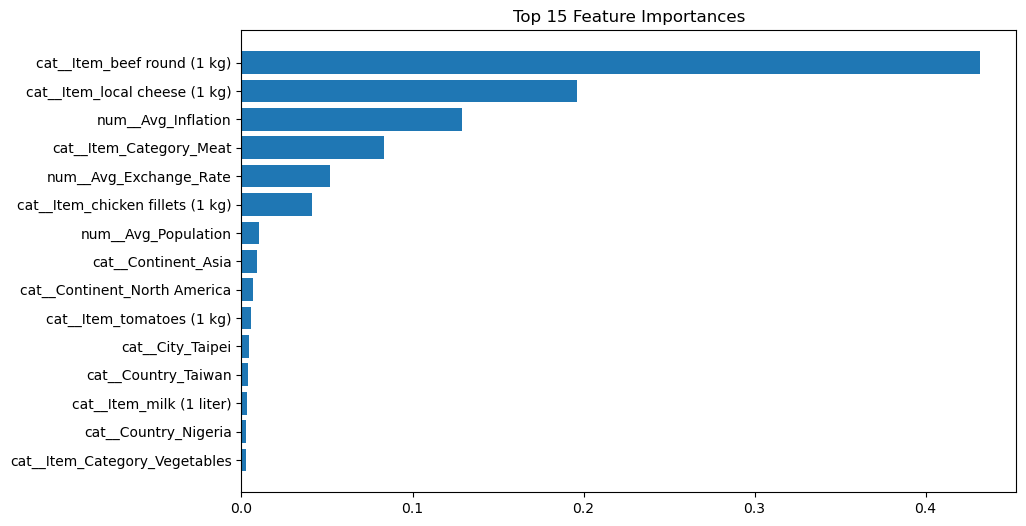

In [29]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.gca().invert_yaxis()
plt.title(
    "Top 15 Feature Importances"
)
plt.show()

## PCA

In [30]:
X_train_processed = (
    preprocessor.fit_transform(X_train)
)

from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_train_processed)


,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


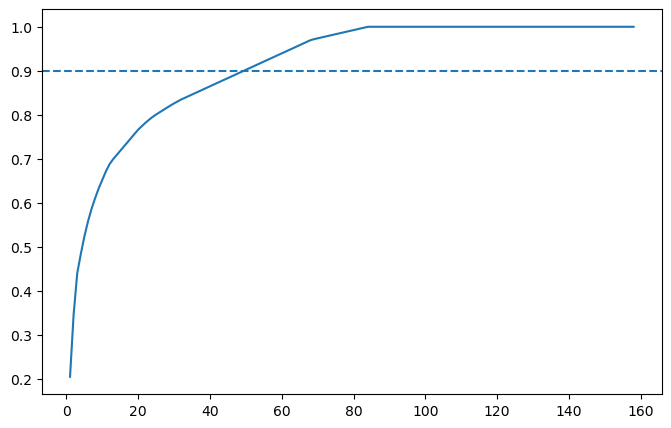

In [31]:
import numpy as np

cum_var = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))
plt.plot(
    range(
        1,
        len(cum_var)+1
    ),
    cum_var
)
plt.axhline(
    0.90,
    linestyle="--"
)
plt.show()

In [32]:
n_90 = np.argmax(
    cum_var >= 0.90
) + 1

print(n_90)

50


In [33]:
pca_2 = PCA(
    n_components=2
)

X_pca = pca_2.fit_transform(
    X_train_processed
)

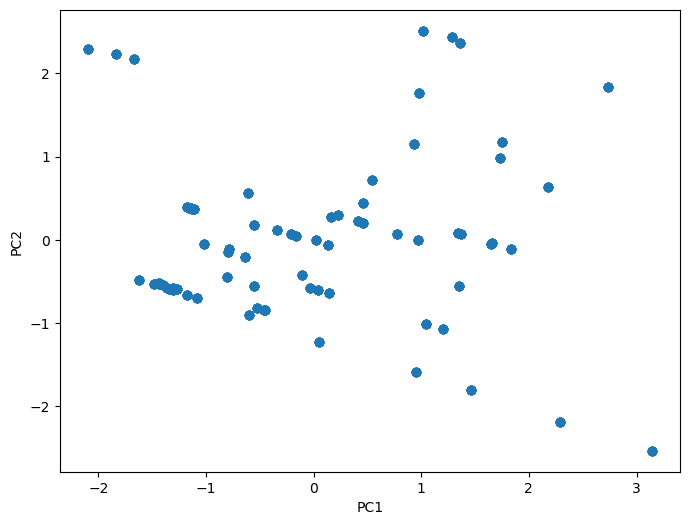

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Clustering

In [35]:
from sklearn.decomposition import PCA
import numpy as np

X_train_processed = preprocessor.fit_transform(X_train)

pca_full = PCA()
pca_full.fit(X_train_processed)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

n_90 = np.argmax(cum_var >= 0.90) + 1

print("Components needed for 90% variance:", n_90)

Components needed for 90% variance: 50


In [36]:
pca_90 = PCA(n_components=n_90)

X_train_pca_90 = pca_90.fit_transform(X_train_processed)

In [37]:
pca_2 = PCA(n_components=2)

X_train_pca_2 = pca_2.fit_transform(X_train_processed)

### K-means

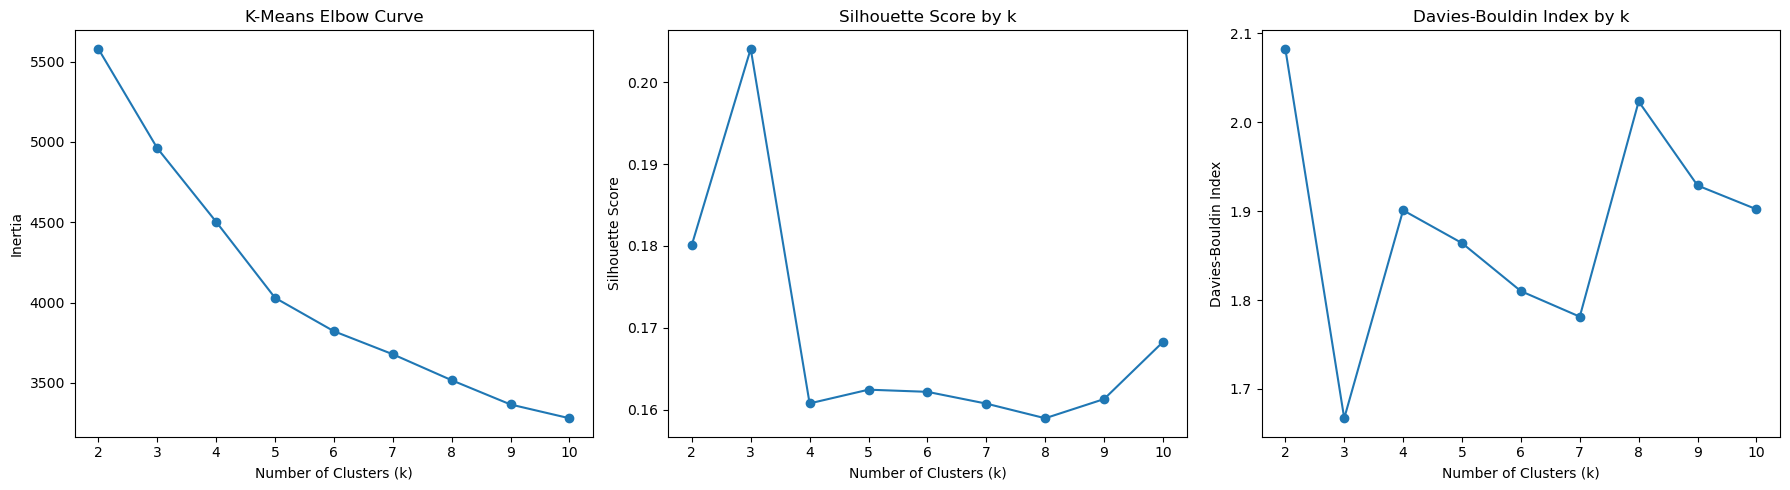

,k,Inertia,Silhouette,Davies_Bouldin
0,2,5579.265526,0.180125,2.082697
1,3,4961.513928,0.204096,1.667003
2,4,4503.182671,0.160746,1.901024
3,5,4030.059799,0.162424,1.864093
4,6,3822.121158,0.162161,1.810044
5,7,3678.834793,0.160721,1.781289
6,8,3517.288322,0.158931,2.023454
7,9,3366.317200,0.161275,1.928904
8,10,3280.655013,0.168255,1.902166


In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd
import matplotlib.pyplot as plt

k_values = range(2, 11)

kmeans_results = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = km.fit_predict(X_train_pca_90)
    
    kmeans_results.append({
        "k": k,
        "Inertia": km.inertia_,
        "Silhouette": silhouette_score(X_train_pca_90, labels),
        "Davies_Bouldin": davies_bouldin_score(X_train_pca_90, labels)
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(kmeans_results_df["k"], kmeans_results_df["Inertia"], marker="o")
axes[0].set_title("K-Means Elbow Curve")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(kmeans_results_df["k"], kmeans_results_df["Silhouette"], marker="o")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

axes[2].plot(kmeans_results_df["k"], kmeans_results_df["Davies_Bouldin"], marker="o")
axes[2].set_title("Davies-Bouldin Index by k")
axes[2].set_xlabel("Number of Clusters (k)")
axes[2].set_ylabel("Davies-Bouldin Index")

plt.tight_layout()
plt.show()

kmeans_results_df

In [39]:
best_k = kmeans_results_df.sort_values(
    ["Silhouette", "Davies_Bouldin"],
    ascending=[False, True]
).iloc[0]["k"]

best_k = int(best_k)

print("Best k:", best_k)

Best k: 3


In [40]:
best_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = best_kmeans.fit_predict(X_train_pca_90)

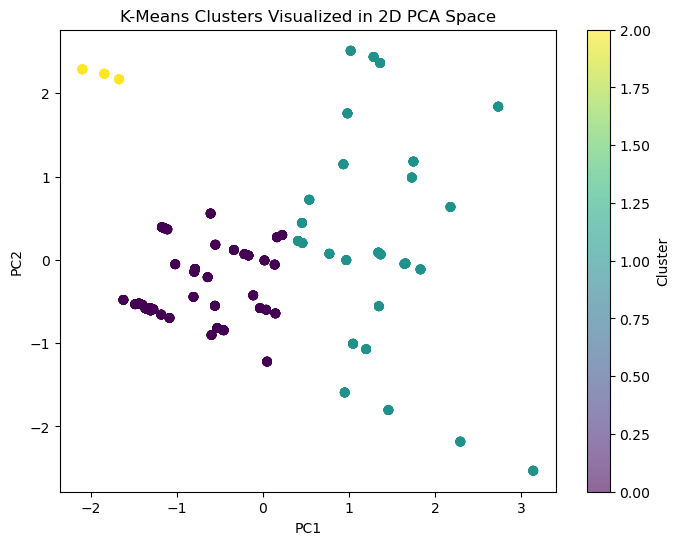

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    X_train_pca_2[:, 0],
    X_train_pca_2[:, 1],
    c=kmeans_labels,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters Visualized in 2D PCA Space")
plt.colorbar(label="Cluster")
plt.show()

Working with 50 PCA features that previously explianed +%90 of the variance, we chose number of clusters as 3.

In [42]:
best_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = best_kmeans.fit_predict(X_train_pca_90)

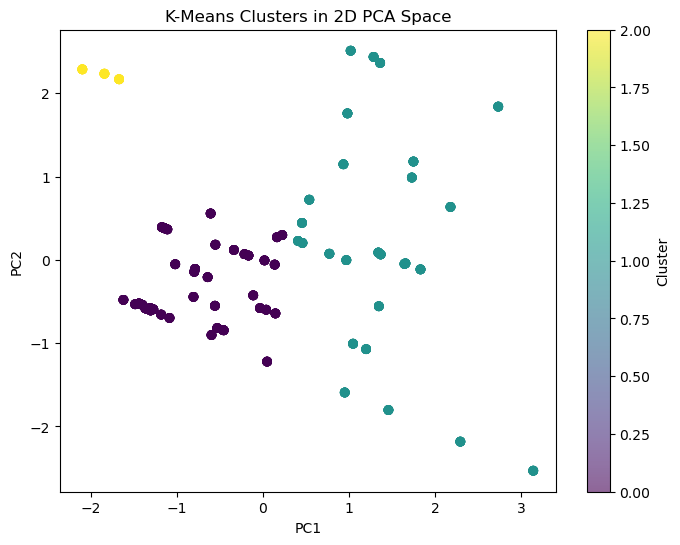

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_pca_2[:, 0],
    X_train_pca_2[:, 1],
    c=kmeans_labels,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters in 2D PCA Space")
plt.colorbar(label="Cluster")
plt.show()

In [44]:
train_cluster_analysis = train_df_final.copy()
train_cluster_analysis["KMeans_Cluster"] = kmeans_labels

In [45]:
pd.crosstab(
    train_cluster_analysis["KMeans_Cluster"],
    train_cluster_analysis["Item_Category"],
    normalize="index"
)

Item_Category,Bakery,Dairy,Dairy & Eggs,Fruits,Grains,Meat,Vegetables
KMeans_Cluster,,,,,,,
0,0.071429,0.142857,0.071429,0.214286,0.071429,0.142857,0.285714
1,0.071429,0.142857,0.071429,0.214286,0.071429,0.142857,0.285714
2,0.071429,0.142857,0.071429,0.214286,0.071429,0.142857,0.285714


In [46]:
cluster_price_summary = (
    train_cluster_analysis
    .groupby("KMeans_Cluster")["Future_Avg_Price"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

cluster_price_summary

,KMeans_Cluster,count,mean,median,std
0,0,588,5.159807,2.786667,5.655326
1,1,378,3.454700,1.795000,4.569934
2,2,42,4.007937,2.448333,4.355673


In [47]:
pd.crosstab(
    train_cluster_analysis["KMeans_Cluster"],
    train_cluster_analysis["Continent"],
    normalize="index"
)

Continent,Africa,Asia,Europe,North America,Oceania,South America
KMeans_Cluster,,,,,,
0,0.000000,0.095238,0.666667,0.142857,0.047619,0.047619
1,0.222222,0.518519,0.111111,0.000000,0.000000,0.148148
2,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000


In [48]:
train_cluster_analysis.groupby("KMeans_Cluster")[
    [
        "Avg_Exchange_Rate",
        "Avg_Inflation",
        "Avg_FAO_Index",
        "Avg_Population",
        "Future_Avg_Price"
    ]
].mean()

,Avg_Exchange_Rate,Avg_Inflation,Avg_FAO_Index,Avg_Population,Future_Avg_Price
KMeans_Cluster,,,,,
0,0.712927,4.164286,126.366667,1.779797e+06,5.159807
1,0.022868,6.755556,126.366667,9.220820e+06,3.454700
2,2.836667,8.900000,126.366667,1.607136e+06,4.007937


We see all three clusters had the same item distribution and therefore not ranked by items, we later checked, if regions or economic factors were in effect. It is plausible to believe they are ranked by continent since cluster 3 was only asian and cluster 1 was mostly europe.

Apparently the region means the most here as a geographic factor, as it generally gives a good idea of economics as well.

### GMM

In [49]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd

gmm_results = []

for n in range(2, 11):
    for cov_type in ["full", "tied", "diag"]:
        gmm = GaussianMixture(
            n_components=n,
            covariance_type=cov_type,
            random_state=42
        )
        
        labels = gmm.fit_predict(X_train_pca_90)
        
        gmm_results.append({
            "n_components": n,
            "covariance_type": cov_type,
            "BIC": gmm.bic(X_train_pca_90),
            "AIC": gmm.aic(X_train_pca_90),
            "Silhouette": silhouette_score(X_train_pca_90, labels),
            "Davies_Bouldin": davies_bouldin_score(X_train_pca_90, labels)
        })

gmm_results_df = pd.DataFrame(gmm_results)
gmm_results_df.sort_values("BIC").head(10)

,n_components,covariance_type,BIC,AIC,Silhouette,Davies_Bouldin
15,7,full,-227599.219235,-273222.048561,0.140847,2.075882
24,10,full,-222621.144794,-287798.721999,0.151578,1.885971
12,6,full,-220179.398418,-259283.978452,0.123580,2.097486
21,9,full,-206362.530385,-265021.858298,0.149144,1.849298
18,8,full,-203988.929867,-256130.008487,0.148450,1.874137
9,5,full,-188177.166961,-220763.497702,0.164784,1.886767
6,4,full,-179934.820912,-206002.902360,0.145033,2.008678
3,3,full,-102668.128258,-122217.960413,0.204096,1.667003
0,2,full,-92701.953256,-105733.536119,0.180125,2.082697
23,9,diag,-46419.386219,-50882.863110,0.108010,2.051403


In [50]:
best_gmm_row = gmm_results_df.sort_values("BIC").iloc[0]

best_n = int(best_gmm_row["n_components"])
best_cov = best_gmm_row["covariance_type"]

print("Best GMM components:", best_n)
print("Best covariance type:", best_cov)

Best GMM components: 7
Best covariance type: full


In [51]:
best_gmm = GaussianMixture(
    n_components=best_n,
    covariance_type=best_cov,
    random_state=42
)

gmm_labels = best_gmm.fit_predict(X_train_pca_90)

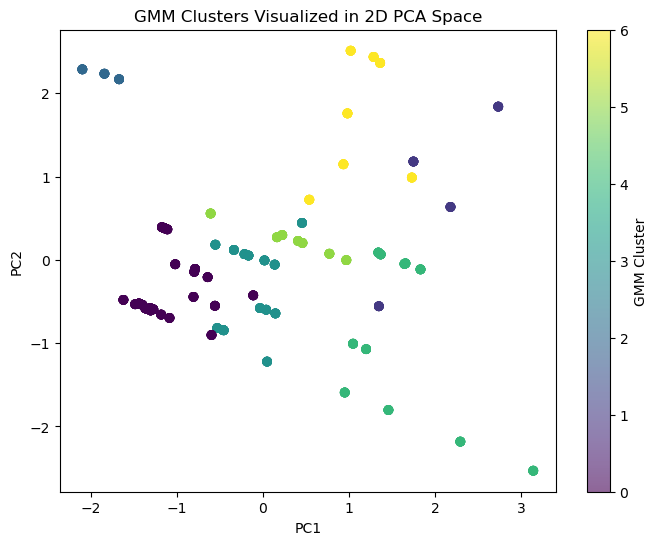

In [52]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_pca_2[:, 0],
    X_train_pca_2[:, 1],
    c=gmm_labels,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters Visualized in 2D PCA Space")
plt.colorbar(label="GMM Cluster")
plt.show()

In [53]:
clustering_comparison = pd.DataFrame({
    "Method": ["K-Means", "GMM"],
    "Clusters": [best_k, best_n],
    "Silhouette": [
        silhouette_score(X_train_pca_90, kmeans_labels),
        silhouette_score(X_train_pca_90, gmm_labels)
    ],
    "Davies_Bouldin": [
        davies_bouldin_score(X_train_pca_90, kmeans_labels),
        davies_bouldin_score(X_train_pca_90, gmm_labels)
    ]
})

clustering_comparison

,Method,Clusters,Silhouette,Davies_Bouldin
0,K-Means,3,0.204096,1.667003
1,GMM,7,0.140847,2.075882


As the second method I chose GMM, as it is a different probablistic method. We did not really have much meaning clustering here compared to kmeans, performance scores are comparable though. We ll shortly compare it by adding these columns to the gradboost model we had.

## GradBoost with Clusters

In [54]:
def evaluate_cluster_feature_model(
    cluster_name,
    train_labels,
    val_labels,
    test_labels
):
    train_df_cluster = train_df_final.copy()
    val_df_cluster = val_df.copy()
    test_df_cluster = test_df.copy()

    train_df_cluster["Cluster_Label"] = train_labels
    val_df_cluster["Cluster_Label"] = val_labels
    test_df_cluster["Cluster_Label"] = test_labels

    feature_cols_cluster = feature_cols_no_price + ["Cluster_Label"]

    X_train_cluster = train_df_cluster[feature_cols_cluster]
    X_val_cluster = val_df_cluster[feature_cols_cluster]
    X_test_cluster = test_df_cluster[feature_cols_cluster]

    categorical_features_cluster = categorical_features + ["Cluster_Label"]
    numeric_features_cluster = numeric_features

    preprocessor_cluster = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_cluster),
            ("num", StandardScaler(), numeric_features_cluster)
        ]
    )

    model = Pipeline(steps=[
        ("preprocessor", preprocessor_cluster),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=3,
            min_samples_leaf=10,
            random_state=42
        ))
    ])

    model.fit(X_train_cluster, y_train)

    val_preds = model.predict(X_val_cluster)
    test_preds = model.predict(X_test_cluster)

    return {
        "Model": f"Gradient Boosting + {cluster_name}",
        "Validation RMSE": np.sqrt(mean_squared_error(y_val, val_preds)),
        "Validation MAE": mean_absolute_error(y_val, val_preds),
        "Validation R2": r2_score(y_val, val_preds),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
        "Test MAE": mean_absolute_error(y_test, test_preds),
        "Test R2": r2_score(y_test, test_preds)
    }

In [55]:
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

X_val_pca_90 = pca_90.transform(X_val_processed)
X_test_pca_90 = pca_90.transform(X_test_processed)

kmeans_val_labels = best_kmeans.predict(X_val_pca_90)
kmeans_test_labels = best_kmeans.predict(X_test_pca_90)

gmm_val_labels = best_gmm.predict(X_val_pca_90)
gmm_test_labels = best_gmm.predict(X_test_pca_90)

In [56]:
cluster_feature_results = []

cluster_feature_results.append(
    evaluate_cluster_feature_model(
        "K-Means Cluster",
        kmeans_labels,
        kmeans_val_labels,
        kmeans_test_labels
    )
)

cluster_feature_results.append(
    evaluate_cluster_feature_model(
        "GMM Cluster",
        gmm_labels,
        gmm_val_labels,
        gmm_test_labels
    )
)

cluster_feature_results_df = pd.DataFrame(cluster_feature_results)


In [57]:
baseline_gb_result = tuned_results_df[
    tuned_results_df["Model"] == "Gradient Boosting"
][
    ["Model", "Validation RMSE", "Validation MAE", "Validation R2"]
].copy()

baseline_gb_result["Model"] = "Gradient Boosting"

cluster_feature_comparison = pd.concat(
    [
        baseline_gb_result,
        cluster_feature_results_df[
            ["Model", "Validation RMSE", "Validation MAE", "Validation R2"]
        ]
    ],
    ignore_index=True
)

cluster_feature_comparison

,Model,Validation RMSE,Validation MAE,Validation R2
0,Gradient Boosting,2.838569,1.485715,0.798812
1,Gradient Boosting + K-Means Cluster,2.854787,1.515944,0.796507
2,Gradient Boosting + GMM Cluster,2.869238,1.492199,0.794442


As it can be seen GMM with that many clusters didnt add meaningful input at all, so it reduced our performance. Whereas k means clustered data by continents which repeated the original data therefore slightly reducing the gradboost performance.

In [ ]:
test_results = []

for name, model in best_models.items():
    test_preds = model.predict(X_test)
    
    test_results.append({
        "Model": name,
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
        "Test MAE": mean_absolute_error(y_test, test_preds),
        "Test R2": r2_score(y_test, test_preds)
    })

test_results_df = pd.DataFrame(test_results)

In [ ]:
final_model_comparison = tuned_results_df.merge(
    test_results_df,
    on="Model",
    how="left"
)

# Final Comparison Table


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor


def regression_metrics(y_true, y_pred, prefix):
    return {
        f"{prefix} RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        f"{prefix} MAE": mean_absolute_error(y_true, y_pred),
        f"{prefix} R2": r2_score(y_true, y_pred),
    }


final_rows = []

for name, model in best_models.items():
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)
    test_preds = model.predict(X_test)

    tuned_row = tuned_results_df.loc[tuned_results_df["Model"] == name].iloc[0]

    row = {
        "Model": name,
        "Feature Set": "No price history",
        "CV RMSE": tuned_row["CV RMSE"],
        "Best Parameters": tuned_row["Best Parameters"],
    }
    row.update(regression_metrics(y_train, train_preds, "Train"))
    row.update(regression_metrics(y_val, val_preds, "Validation"))
    row.update(regression_metrics(y_test, test_preds, "Test"))
    final_rows.append(row)



train_df_kmeans = train_df_final.copy()
val_df_kmeans = val_df.copy()
test_df_kmeans = test_df.copy()

train_df_kmeans["Cluster_Label"] = kmeans_labels
val_df_kmeans["Cluster_Label"] = kmeans_val_labels
test_df_kmeans["Cluster_Label"] = kmeans_test_labels

feature_cols_kmeans = feature_cols_no_price + ["Cluster_Label"]

X_train_kmeans = train_df_kmeans[feature_cols_kmeans]
X_val_kmeans = val_df_kmeans[feature_cols_kmeans]
X_test_kmeans = test_df_kmeans[feature_cols_kmeans]

categorical_features_kmeans = categorical_features + ["Cluster_Label"]
numeric_features_kmeans = numeric_features

preprocessor_kmeans = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_kmeans),
        ("num", StandardScaler(), numeric_features_kmeans),
    ]
)

gb_kmeans_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_kmeans),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.1,
                max_depth=3,
                min_samples_leaf=10,
                random_state=42,
            ),
        ),
    ]
)

gb_kmeans_model.fit(X_train_kmeans, y_train)

gb_kmeans_train_preds = gb_kmeans_model.predict(X_train_kmeans)
gb_kmeans_val_preds = gb_kmeans_model.predict(X_val_kmeans)
gb_kmeans_test_preds = gb_kmeans_model.predict(X_test_kmeans)

gb_kmeans_row = {
    "Model": "Gradient Boosting + K-Means Cluster",
    "Feature Set": "No price history + K-Means cluster label",
    "CV RMSE": np.nan,
    "Best Parameters": {
        "model__n_estimators": 200,
        "model__learning_rate": 0.1,
        "model__max_depth": 3,
        "model__min_samples_leaf": 10,
        "kmeans__n_clusters": best_k,
    },
}
gb_kmeans_row.update(regression_metrics(y_train, gb_kmeans_train_preds, "Train"))
gb_kmeans_row.update(regression_metrics(y_val, gb_kmeans_val_preds, "Validation"))
gb_kmeans_row.update(regression_metrics(y_test, gb_kmeans_test_preds, "Test"))
final_rows.append(gb_kmeans_row)

final_no_price_comparison = pd.DataFrame(final_rows)

metric_cols = [
    "CV RMSE",
    "Train RMSE", "Train MAE", "Train R2",
    "Validation RMSE", "Validation MAE", "Validation R2",
    "Test RMSE", "Test MAE", "Test R2",
]

final_no_price_comparison[metric_cols] = final_no_price_comparison[metric_cols].round(4)

final_no_price_comparison = final_no_price_comparison[
    [
        "Model", "Feature Set", "CV RMSE",
        "Train RMSE", "Train MAE", "Train R2",
        "Validation RMSE", "Validation MAE", "Validation R2",
        "Test RMSE", "Test MAE", "Test R2",
        "Best Parameters",
    ]
].sort_values("Test RMSE", ascending=True).reset_index(drop=True)

final_no_price_comparison


,Model,Feature Set,CV RMSE,Train RMSE,Train MAE,Train R2,Validation RMSE,Validation MAE,Validation R2,Test RMSE,Test MAE,Test R2,Best Parameters
0,Gradient Boosting,No price history,2.0479,1.4197,0.7886,0.9277,2.8386,1.4857,0.7988,1.4920,0.9069,0.8932,"{'model__learning_rate': 0.1, 'model__max_dept..."
1,Gradient Boosting + K-Means Cluster,No price history + K-Means cluster label,NaN,1.4450,0.7961,0.9251,2.8548,1.5159,0.7965,1.5210,0.9270,0.8890,"{'model__n_estimators': 200, 'model__learning_..."
2,Random Forest,No price history,2.3679,2.0582,1.0734,0.8481,3.1190,1.5666,0.7571,1.6963,1.0660,0.8619,"{'model__max_depth': 8, 'model__max_features':..."
3,Decision Tree,No price history,2.4913,2.2405,1.2750,0.8199,3.1815,1.7460,0.7473,2.0834,1.3066,0.7917,"{'model__max_depth': 6, 'model__min_samples_le..."
4,Ridge Regression,No price history,2.6695,2.3588,1.3240,0.8004,3.6409,2.0234,0.6690,2.1103,1.3721,0.7863,{'model__alpha': 10}


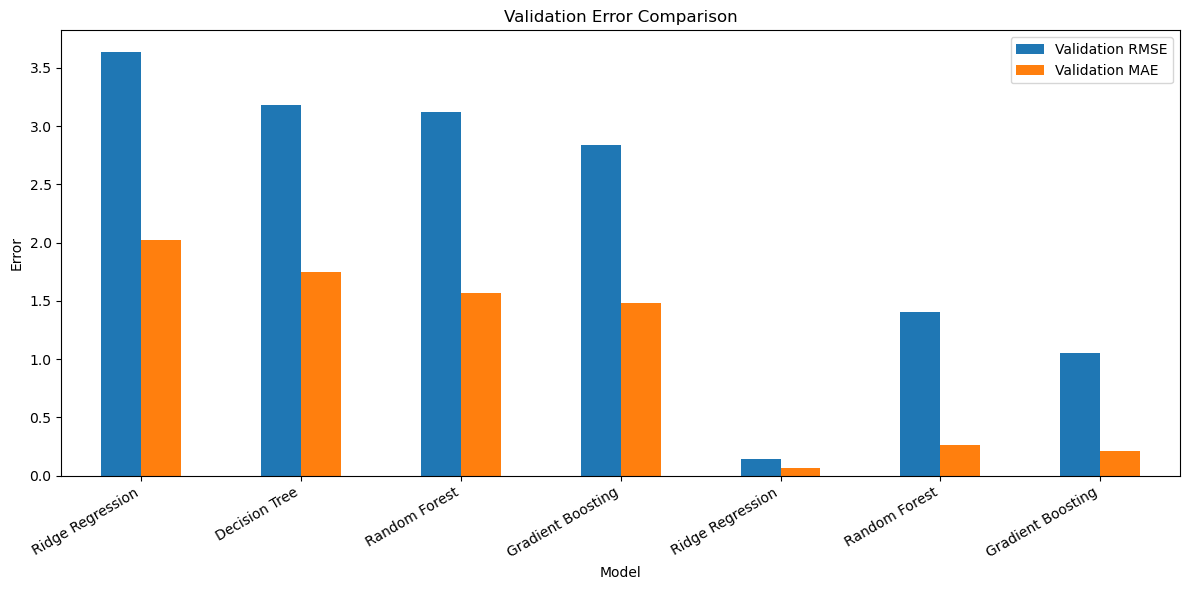

In [64]:
comparison_df.columns = comparison_df.columns.str.strip()

plot_df = comparison_df.set_index("Model")

plot_df[["Validation RMSE", "Validation MAE"]].plot(kind="bar", figsize=(12, 6))
plt.title("Validation Error Comparison")
plt.ylabel("Error")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

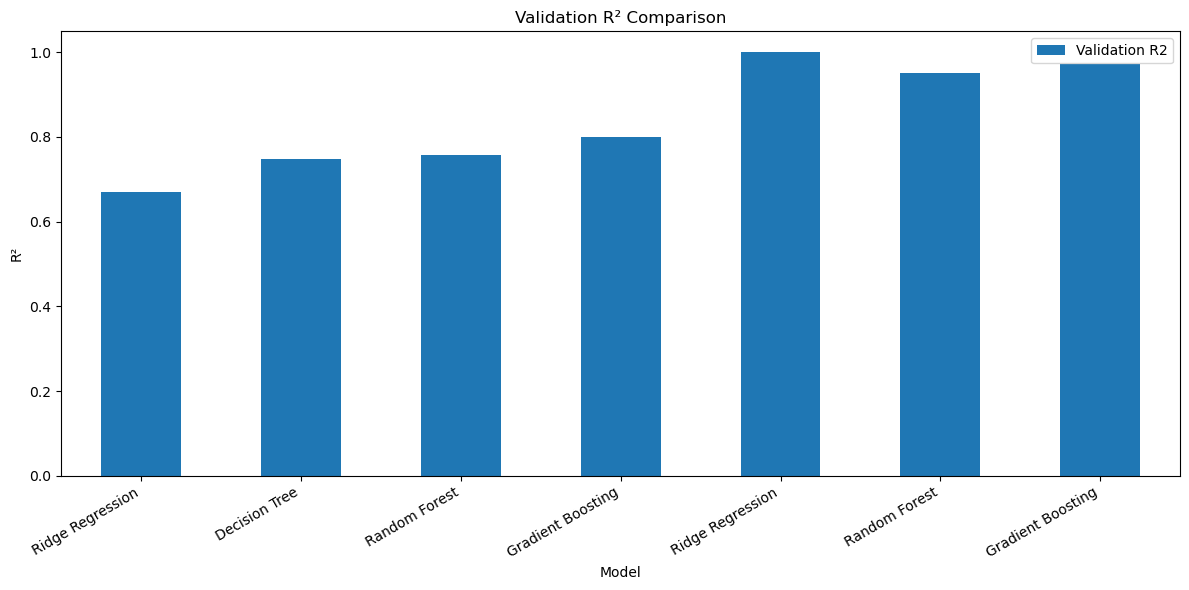

In [65]:
plot_df[["Validation R2"]].plot(kind="bar", figsize=(12, 6))
plt.title("Validation R² Comparison")
plt.ylabel("R²")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Evaluation


The validation results show that Gradboost had the best  performance among the no-price models. It produced the lowest validation RMSE while also achieving the highest validation R². This shows that it has seen the nonlinear relationships in the feature set better than the simpler models.

The Gradient Boosting + K-Means version can be compared against the normal model to see whether clustering improved the algorithm. However slightly lower scores indicate clusters likely seen structure in the features we had, however didnt improve our model. (introduced same continent column but with signals here)

Random forest did not improve our results and decision trees simply tried to overfit the data we had, ridge regression on the other hand did not present any usefulness since we dropped price history data. Thus gradboost is the best model for our dataset

# Error Analysis

In [ ]:
best_model = grid.best_estimator_  

y_pred = best_model.predict(X_test_price)

residuals = y_test - y_pred
absolute_errors = abs(residuals)

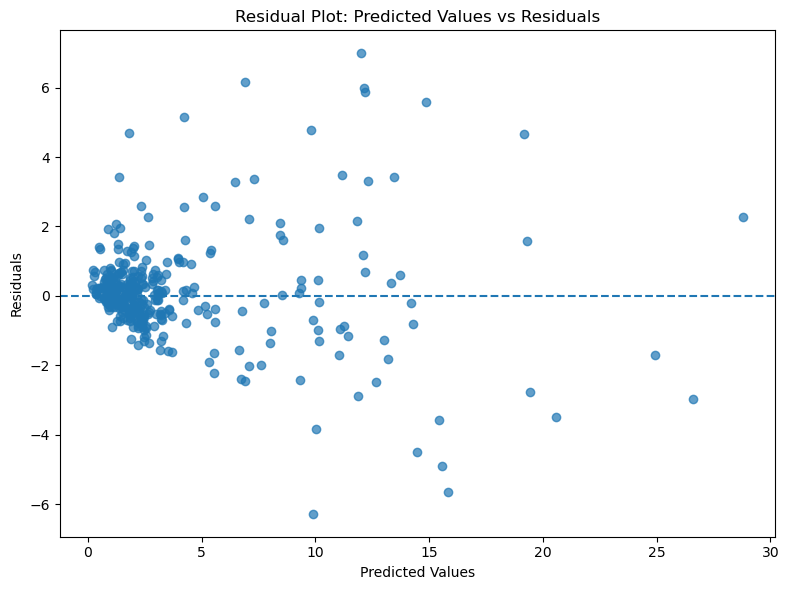

In [69]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot: Predicted Values vs Residuals")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

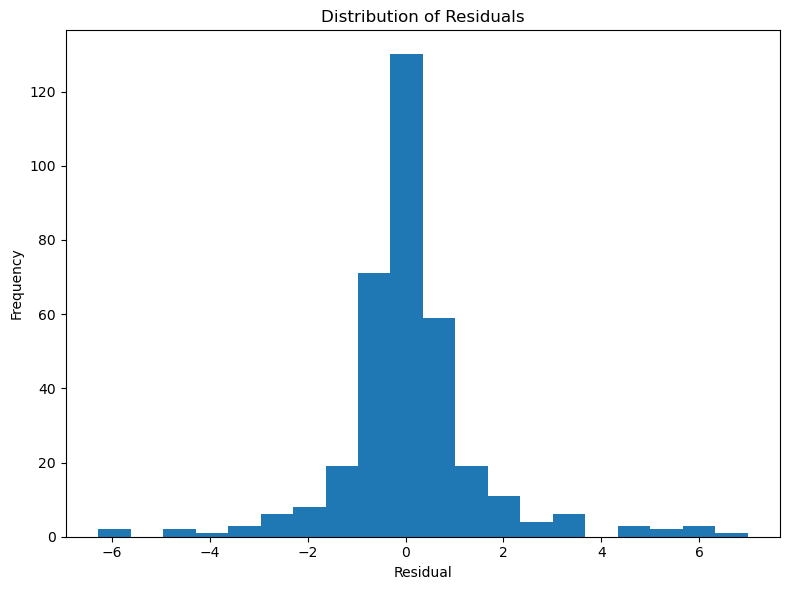

In [70]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [75]:
analysis_df = X_test.copy()

analysis_df["Actual"] = y_test.values
analysis_df["Predicted"] = y_pred
analysis_df["Residual"] = analysis_df["Actual"] - analysis_df["Predicted"]
analysis_df["Absolute Error"] = analysis_df["Residual"].abs()

analysis_df.head()
analysis_df["Error Category"] = pd.cut(
    analysis_df["Absolute Error"],
    bins=[-np.inf, 1, 2, 4, np.inf],
    labels=["Low error", "Moderate error", "High error", "Very high error"]
)
for col in ["item_category", "continent"]:
    if col in analysis_df.columns:
        display(
            analysis_df.groupby(col)["Absolute Error"]
            .agg(["count", "mean", "median", "max"])
            .sort_values("mean", ascending=False)
        )
analysis_df.columns.tolist()

['Country',
 'City',
 'Item',
 'Item_Category',
 'Continent',
 'Avg_Exchange_Rate',
 'Avg_Inflation',
 'Avg_FAO_Index',
 'Avg_Population',
 'Actual',
 'Predicted',
 'Residual',
 'Absolute Error',
 'Error Category']

C:\Users\ab165988\AppData\Local\Temp\ipykernel_3584\2548996047.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = analysis_df.select_dtypes(include=["object", "category"]).columns.tolist()


,count,mean,median,max
Continent,,,,
Asia,196,1.058588,0.583934,6.989256
Oceania,14,0.954224,0.632550,2.838226
Africa,14,0.785013,0.474378,2.881286
North America,42,0.763791,0.469966,3.824716
Europe,56,0.701564,0.338957,5.591584
South America,28,0.508034,0.289733,2.459195


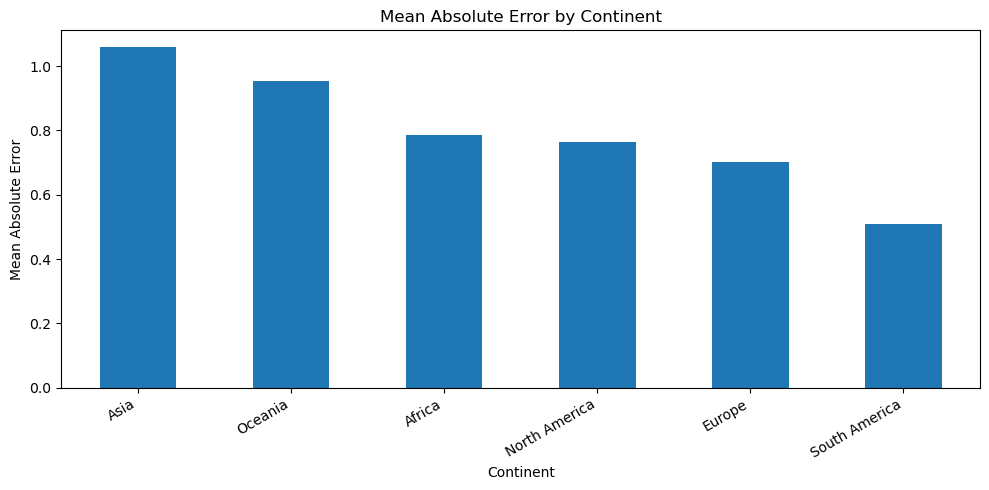

In [ ]:
cat_cols = analysis_df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols
for col in ["item_category", "continent"]:
    if col in analysis_df.columns:
        display(
            analysis_df.groupby(col)["Absolute Error"]
            .agg(["count", "mean", "median", "max"])
            .sort_values("mean", ascending=False)
        )
analysis_df.columns.tolist()
for col in ["Item Category", "Continent"]:
    if col in analysis_df.columns:
        display(
            analysis_df.groupby(col)["Absolute Error"]
            .agg(["count", "mean", "median", "max"])
            .sort_values("mean", ascending=False)
        )
col = "Continent"   

analysis_df.groupby(col)["Absolute Error"].mean().sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(f"Mean Absolute Error by {col}")
plt.ylabel("Mean Absolute Error")
plt.xlabel(col)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
very_high = analysis_df[analysis_df["Error Category"] == "Very high error"]

for col in ["item_category", "continent"]:
    if col in very_high.columns:
        display(very_high[col].value_counts())

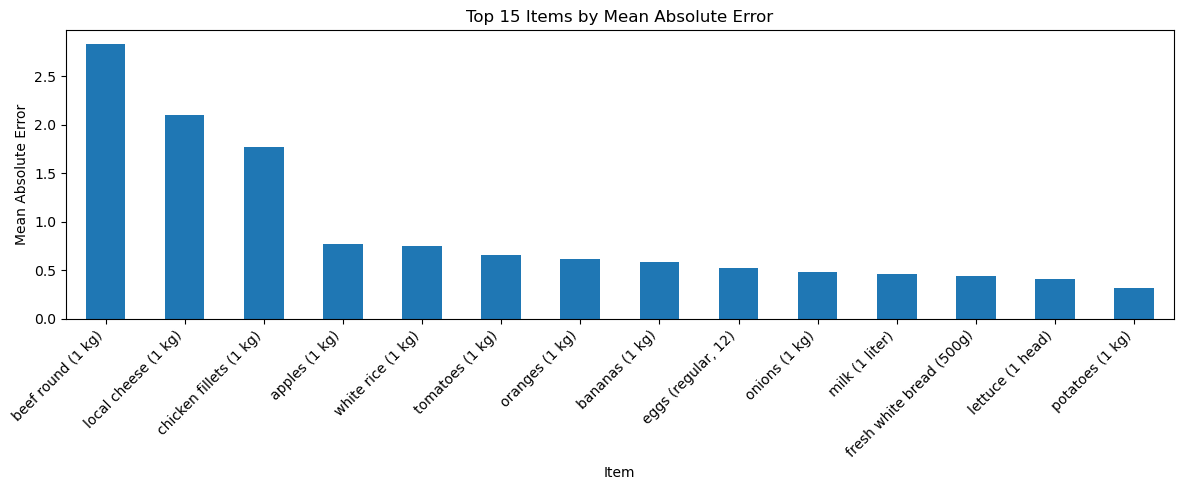

In [ ]:
item_col = "Item"  

analysis_df.groupby(item_col)["Absolute Error"].mean().sort_values(ascending=False).head(15).plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Top 15 Items by Mean Absolute Error")
plt.ylabel("Mean Absolute Error")
plt.xlabel("Item")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Final Written Report

## Introduction

The goal of this project was to predict global food prices using geographic and economic information. The dataset contains six months of price history for 14 food products collected from many cities around the world, also with economic indicators such as inflation, exchange rates, FAO food indices, and population estimates. Food prices are closely connected to inflation and living costs, meaning accurate predictions would be useful for making better decisions for the people, businesses or goverments.

The challange here was the limited span of our data only having 6 months of prices, that's why it was not obvious whether the models may learn meaningful economic relationships or simply focus on seeing a pattern from previous months prices.

## Methods

The project is done in 3 parts. In part 1 we did explatory data analysis we cleaned our data, investigated it, made distrubitons, checked the relations between variables. Boxplots, category comparisons and geographic visuals helped us a lot in understanding what affects food prices.  

In part 2, we formulated the problem as a regression task where given 3 first three months price data, how accurate we can predict the following three months. Multiple Linear Regression, Polynomial Regression, Ridge Regression, and Lasso Regression were evaluated using train-test splits and cross-validation. Multiple Linear Regression, Polynomial Regression, Ridge Regression, and Lasso Regression were evaluated using train-test splits and cross-validation.

In part 3, we changed our focus to the information that existed beyond price data, thus we trained new models without using previous price data. Decision Trees, Random Forests, Gradient Boosting, and K-Means models were compared. PCA and clustering were also used to explore patterns in the dataset.

## Results

The exploratory analysis revealed that food prices varied much more strongly across item categories than across months. Fruits and vegetables showed noticeable seasonal changes, while meat and dairy products as a category showed different signals. Inflation displayed the strongest correlation with prices among the variables, but they were much weaker than we expected, which suggested other factors not included in our dataset influenced prices as well.

The most surprise we had was in part 2 where we did regression. When we included previous months prices to predict the upcoming months, all models showed extremely high performance. Even the baseline model had a R2 value of 0.998 while having low RMSE values. Adding macroeconomic values didn't even prodouce much better improvements as it was already almost perfect. Price data already contained the most helpful information overshadowing the rest.

Among the regression models, Lasso achieved the best, Ridge with nearly identical results. Polynomial regression showed very apparent overfitting as the degree of the model increased, we have witnessed bias-variance tradeoff quite well here.

The results changed in part 3 where we removed price data as a whole, performance decreased in all models. After tuning gradient boosting achieved the best results outperforming random forest, decision trees and ridge regression. Adding k-means cluster data introduced no improvement to our model.

## Discussion

The results show two very different prediction problems. When  price information was included, all regression models achieved extremely high performance, the choice of algorithm mattered little.  Lasso Regression performed exceptionally well, meaning the relationship is linear.

Training the models without price history were more informative. Performance dropped in all across all models, confirming that previous prices were the strongest predictors in the dataset. However, the models still retained meaningful predictive power. Gradient Boosting achieved the best overall performance with a validation RMSE of 2.84 and a test R² of approximately 0.89, while Random Forest and Decision Tree also explained a large portion of the variance. In contrast, Ridge Regression became the weakest model by far. This suggests that once historical prices are removed, the relationship between food prices and the remaining features becomes more complex and nonlinear. Thus normal regression algorithms cannot handle it. 

Feature importance analysis showed valuable findings, we expected region country data to dominate the ladder, but it was the other way around. Expensive item categories were a huge factor, but also economic factors like inflation matttered a lot in this setup. Our model being able to capture those influential model being able to capture economics rather than simply relying on price or geographic memorization was very meaningful and possibly most encouraging thing in this project.

Another surprising result was the comparison between Decision Trees and Random Forests. Before tuning hyperparametes, decision tree achieved better performance, however later on when we limited the depth of our trees which previously overfit with a depth of 12, random forest this time showed better performance. 

K- means clustering did not provide additional information beyond what we had in the original dataset, wherein k- means clusters tried to capture continent data instead, thus repetetive features dropped our model performance, GMM tried it with 10 clusters but it didnt capture meaningful stuff and lowered our performance much more.

A limitation of the project is the short time span of the dataset. A longer dataset would likely increase the importance of macroeconomic variables and provide a more realistic test of prediction performance under changing conditions.

## Conclusion

This projects showed global food prices are extremely predictable when price history is avaliable. However, the more interesting finding here is that reasonable predictive performance can still be achieved without direct price information. Gradient Boosting was the best performing model in this setting

Lastly, this project showed us excellent predicting performance doesnt mean deeper understanding. By comparing models with and without price information, we were able to see the difference between simple trend following and trying to learn the relationships between data.